# 03 · Customer segmentation

**Method (spec 12.2-12.3).** K-Means on five behaviour features: log(avg balance), log(total value),
log(avg ticket), transaction count capped at 4, and recency. Each is winsorised at P1/P99 and standardised.
Gender and city are *not* inputs; they are used afterwards to profile the segments (risk R8).
The single-vs-repeat evidence layer (spec layer 1) is kept as a tag on every customer, and RFM scores describe
the segments (layer 3).

The k grid (3-10) was evaluated by `src/c360/segmentation.py::evaluate_k`. Each k takes 6 full K-Means fits
(about 30 s), so the grid was run once and saved to `outputs/segmentation/k_selection.csv`.

In [1]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from c360 import db, viz
from c360.config import FIG_DIR
viz.apply_style()
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")
pd.set_option("display.max_columns", 50)

In [2]:
import json
from c360.segmentation import load_features, Prep, profile
ks = pd.read_csv(ROOT / "outputs" / "segmentation" / "k_selection.csv")
cfg = json.loads((ROOT / "config" / "segments.json").read_text())
ks.pivot(index="k", columns="population", values="silhouette").round(3)

population,JOINT,JOINT_age,REPEAT,SINGLE
k,,,,
3,0.29,0.25,0.29,0.26
4,0.27,0.23,0.28,0.26
5,0.28,0.23,0.26,0.28
6,0.28,0.23,0.25,0.26
7,0.27,0.23,0.25,0.27
8,0.26,0.21,NaN,NaN
9,0.26,0.21,NaN,NaN
10,0.25,0.20,NaN,NaN


## P11 · Elbow (inertia) and P12 · silhouette by k

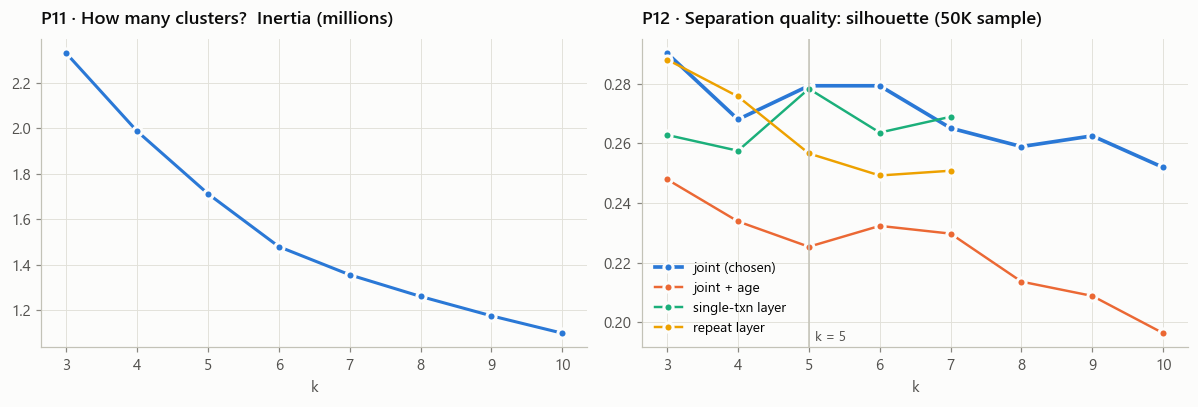

In [3]:
j = ks[ks.population == "JOINT"]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
ax = axes[0]
ax.plot(j.k, j.inertia / 1e6, marker="o", color=viz.SERIES[0], markersize=6, markeredgecolor=viz.SURFACE, markeredgewidth=2)
ax.set_title("P11 · How many clusters?  Inertia (millions)"); ax.set_xlabel("k")
ax = axes[1]
labels = {"JOINT": "joint (chosen)", "JOINT_age": "joint + age", "SINGLE": "single-txn layer", "REPEAT": "repeat layer"}
for i, (pop, lab) in enumerate(labels.items()):
    s = ks[ks.population == pop]
    ax.plot(s.k, s.silhouette, marker="o", color=viz.SERIES[i], markersize=6, markeredgecolor=viz.SURFACE,
            markeredgewidth=2, label=lab, linewidth=2.4 if pop == "JOINT" else 1.6)
ax.axvline(5, color=viz.AXIS, linewidth=1); ax.annotate("k = 5", (5, ax.get_ylim()[0]), xytext=(4, 4), textcoords="offset points", fontsize=9, color=viz.INK_2)
ax.set_title("P12 · Separation quality: silhouette (50K sample)"); ax.set_xlabel("k"); ax.legend(loc="lower left")
fig.tight_layout()
viz.save(fig, "P11_P12_k_selection"); fig

In [4]:
j[["k", "silhouette", "calinski_harabasz", "ari_min", "ari_mean", "min_cluster_share"]].assign(
    min_cluster_share=lambda d: (100 * d.min_cluster_share).round(1)).rename(columns={"min_cluster_share": "smallest cluster %"}).round(3)

,k,silhouette,calinski_harabasz,ari_min,ari_mean,smallest cluster %
0,3,0.29,"20,011.45",0.99,1.00,15.10
1,4,0.27,"18,544.17",0.98,0.98,15.10
2,5,0.28,"18,236.53",0.93,0.97,9.50
3,6,0.28,"18,471.77",0.98,0.99,8.50
4,7,0.27,"17,568.28",1.00,1.00,8.20
5,8,0.26,"16,747.51",0.99,1.00,7.40
6,9,0.26,"16,153.65",0.71,0.88,5.10
7,10,0.25,"15,701.49",0.55,0.85,4.80


In [5]:
print(cfg['selection_note'])

Joint K-Means k=5 chosen over the layered 3+3 design: higher silhouette (0.279 vs ~0.267), every segment >= 3% of customers (layered had a 1.9% segment), ARI >= 0.93 across 5 seeds. Age lowered silhouette at every k, so it is used for profiling only. Single vs repeat (spec layer 1) is kept as the evidence tag.


**What we found.** Silhouette is highest at k = 3 (0.290) and level at k = 5 and 6 (0.279). k = 3 is below the 4-6 target and merges distinct groups. Seed stability is high up to k = 8 (ARI ≥ 0.93) and breaks down at k = 9-10 (min ARI 0.71 and 0.55). Adding age lowers separation at every k, and the layered design (single and repeat clustered separately) does no better than the joint model.

**Why it matters.** The data supports 5 stable, separable groups; more clusters add fragments rather than new behaviour.

**What a manager should do.** (Analyst action.) Use joint K-Means with k = 5 and no age input; re-run the grid when new data arrives (segment drift check).

## Fitted segments

In [6]:
d = load_features()
seg = db.query("SELECT customer_id, segment_id, segment_name, cluster_key, layer FROM customer_segment")
d = d.merge(seg, on="customer_id")
for col in ["total_txn_value", "avg_txn_value", "avg_balance", "latest_balance", "value_score", "engagement_score"]:
    d[col] = d[col].astype(float)
names = d.drop_duplicates("segment_id").sort_values("segment_id")["segment_name"].tolist()
COL = {n: viz.SERIES[i] for i, n in enumerate(names)}       # color follows the segment everywhere
prof = profile(d, d["segment_name"]).loc[names]
prof

,customers,pct_customers,pct_value,mean_txn_count,median_total_value,median_avg_txn,median_avg_balance,mean_recency,pct_active,pct_high_value,median_age,pct_female,pct_tier1_metro,mean_r,mean_f,mean_m
segment,,,,,,,,,,,,,,,,
Engaged Repeat Users,126468,15.03,28.07,2.14,"1,476.00",692.00,"29,936.97",15.30,58.65,28.50,29.00,25.86,44.10,3.77,2.14,4.00
Recent One-Time Spenders,202993,24.12,33.25,1.00,999.00,999.00,"29,017.00",11.12,73.00,24.93,30.00,28.91,46.24,4.19,1.00,3.71
Lapsed One-Time Spenders,214958,25.54,34.32,1.00,999.00,999.00,"28,730.05",35.82,0.00,24.39,30.00,29.66,46.14,1.66,1.00,3.69
Low-Ticket Occasional,217141,25.80,1.65,1.01,100.00,100.00,"12,443.06",22.79,32.98,5.05,27.00,24.35,38.96,2.98,1.01,1.35
Near-Zero Balance,79983,9.50,2.72,1.01,250.00,249.00,86.46,24.81,28.91,1.36,27.00,20.70,40.34,2.78,1.01,2.23


## P13 · Segment profile heat map (z-scores of the clustering features)

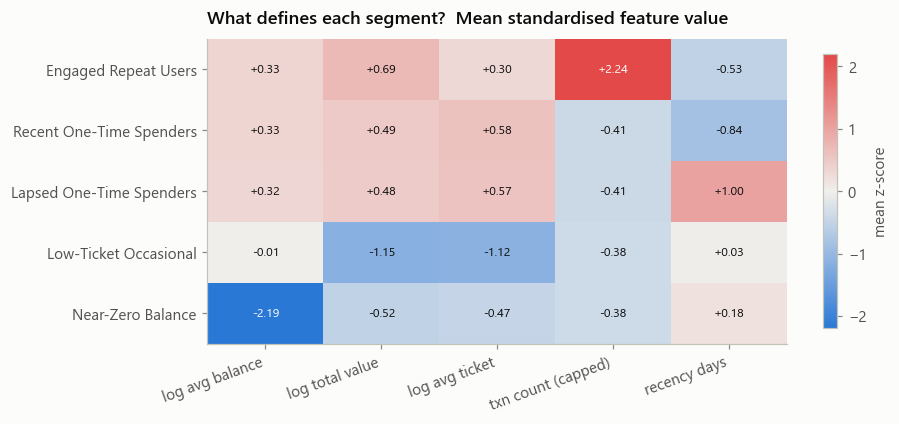

In [7]:
params = json.loads((ROOT / "outputs" / "models" / "segmentation_params.json").read_text())
z = pd.DataFrame(params["zscore_profiles"]["J"]); z.index = z.index.astype(int)
key_to_name = d.drop_duplicates("cluster_key").set_index("cluster_key")["segment_name"]
z.index = [key_to_name[f"J{i}"] for i in z.index]; z = z.loc[names]
z.columns = ["log avg balance", "log total value", "log avg ticket", "txn count (capped)", "recency days"]
from matplotlib.colors import LinearSegmentedColormap
cmap = LinearSegmentedColormap.from_list("div", [viz.DIVERGING[2], viz.DIVERGING[1], viz.DIVERGING[0]])
fig, ax = plt.subplots(figsize=(8.5, 3.6))
im = ax.imshow(z.values, cmap=cmap.reversed(), vmin=-2.2, vmax=2.2, aspect="auto")
ax.set_xticks(range(z.shape[1]), z.columns, rotation=20, ha="right"); ax.set_yticks(range(z.shape[0]), z.index)
ax.grid(False)
for i in range(z.shape[0]):
    for jx in range(z.shape[1]):
        ax.text(jx, i, f"{z.values[i, jx]:+.2f}", ha="center", va="center", fontsize=8,
                color="white" if abs(z.values[i, jx]) > 1.3 else viz.INK)
fig.colorbar(im, ax=ax, label="mean z-score", shrink=0.9)
ax.set_title("What defines each segment?  Mean standardised feature value")
viz.save(fig, "P13_segment_profile"); fig

**What we found.** Each segment has one clear driver:
- Engaged Repeat Users: frequency (+2.24 SD).
- Recent and Lapsed One-Time Spenders: identical value and ticket, opposite recency (-0.84 vs +1.00).
- Low-Ticket Occasional: very small tickets (-1.12) with ordinary balances.
- Near-Zero Balance: balance (-2.19).

**Why it matters.** The segments are easy to explain in one sentence each, which is what makes them usable by branch staff.

**What a manager should do.** Use the one-line driver as the segment's talking point, e.g. 'one good transaction, not seen for five weeks' for Lapsed One-Time Spenders.

## P14 · PCA view of the segments (20K sample, one panel per segment)

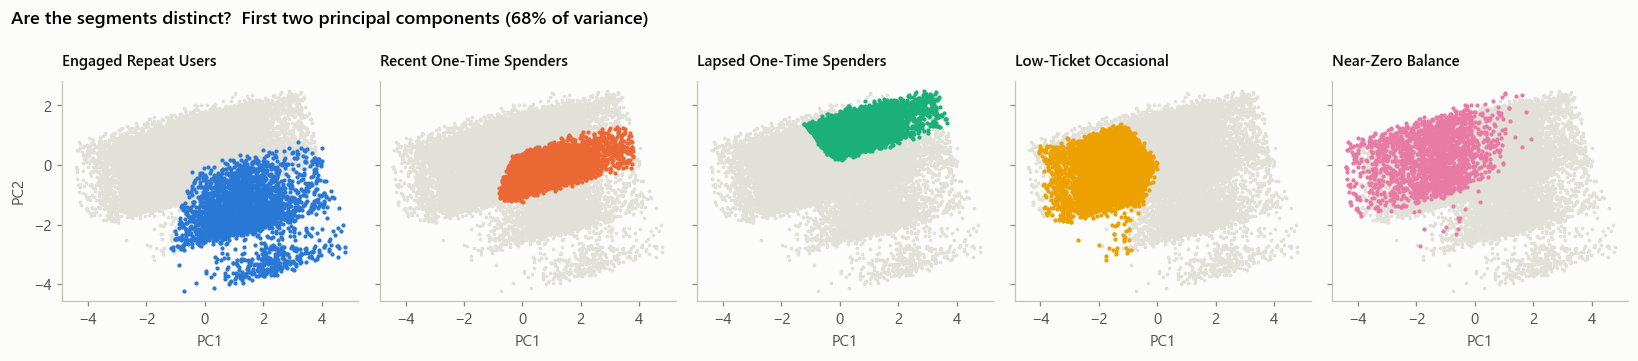

In [8]:
from sklearn.decomposition import PCA
prep = Prep(); X = prep.fit_transform(d)
rng = np.random.default_rng(42); idx = rng.choice(len(d), 20000, replace=False)
pc = PCA(n_components=2, random_state=42).fit(X)
P = pc.transform(X[idx]); lab = d["segment_name"].values[idx]
fig, axes = plt.subplots(1, len(names), figsize=(15, 3.3), sharex=True, sharey=True)
for ax, n in zip(axes, names):
    ax.scatter(P[:, 0], P[:, 1], s=2, color=viz.GRID, rasterized=True)
    m = lab == n
    ax.scatter(P[m, 0], P[m, 1], s=3, color=COL[n], rasterized=True)
    ax.set_title(n, fontsize=10); ax.grid(False)
axes[0].set_ylabel("PC2"); [a.set_xlabel("PC1") for a in axes]
fig.suptitle(f"Are the segments distinct?  First two principal components ({100 * pc.explained_variance_ratio_.sum():.0f}% of variance)",
             x=0.01, ha="left", fontweight="semibold")
fig.tight_layout()
viz.save(fig, "P14_pca_segments"); fig

**What we found.** In the first two principal components (68% of variance), the three one-time segments occupy distinct regions. Engaged Repeat Users spread along their own axis (frequency), and Near-Zero Balance sits at the low-balance edge. The overlap is at the boundaries, as expected for continuous behaviour.

**Why it matters.** The clusters reflect real differences rather than artefacts of the algorithm, though the boundaries are soft.

**What a manager should do.** Treat customers near a boundary (for example a 'Recent' spender about to lapse) as candidates for the neighbouring segment's action too.

## P15 · Segment size vs value share

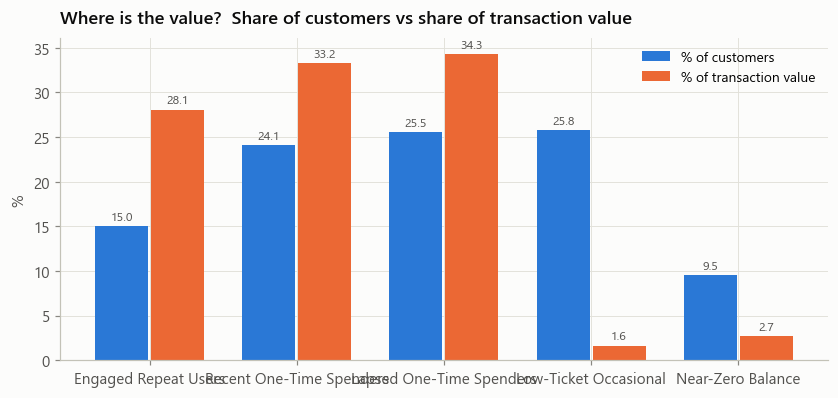

In [9]:
fig, ax = plt.subplots(figsize=(9, 3.8))
x = np.arange(len(names)); w = 0.36
b1 = ax.bar(x - w / 2 - 0.01, prof["pct_customers"], w, color=viz.SERIES[0], label="% of customers")
b2 = ax.bar(x + w / 2 + 0.01, prof["pct_value"], w, color=viz.SERIES[1], label="% of transaction value")
for bars in (b1, b2):
    for r in bars:
        ax.annotate(f"{r.get_height():.1f}", (r.get_x() + r.get_width() / 2, r.get_height()), ha="center", va="bottom",
                    xytext=(0, 2), textcoords="offset points", fontsize=8, color=viz.INK_2)
ax.set_xticks(x, names); ax.set_ylabel("%"); ax.legend(loc="upper right")
ax.set_title("Where is the value?  Share of customers vs share of transaction value")
viz.save(fig, "P15_segment_size_value"); fig

**What we found.** Engaged Repeat Users are 15.0% of customers and generate 28.1% of transaction value. Recent and Lapsed One-Time Spenders together are 49.7% of customers and 67.6% of value. Low-Ticket Occasional (25.8% of customers) produce only 1.7% of value, and Near-Zero Balance (9.5%) produce 2.7%.

**Why it matters.** Over a third of customers (35%) account for under 5% of value, so RM time spent there has little return; the lapsed group holds a third of value and is not being seen.

**What a manager should do.** Put RM effort on Engaged Repeat Users and Lapsed One-Time Spenders. Serve the two low-value segments through low-cost digital channels.

## Validation (FR-027)

In [10]:
from scipy import stats
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score
val = {}
val["smallest segment (% of customers)"] = round(prof["pct_customers"].min(), 2)
row = j.set_index("k").loc[cfg["k"]["J"]]
val["silhouette (50K sample)"] = round(row.silhouette, 3)
val["ARI across 5 seeds (min / mean)"] = f"{row.ari_min:.3f} / {row.ari_mean:.3f}"
# Hierarchical (Ward) on a 15K sample as an independent check (spec 12.1)
hidx = rng.choice(len(d), 15000, replace=False)
ward = AgglomerativeClustering(n_clusters=cfg["k"]["J"], linkage="ward").fit_predict(X[hidx])
val["ARI K-Means vs Ward hierarchical (15K sample)"] = round(adjusted_rand_score(d["cluster_key"].values[hidx], ward), 3)
pd.Series(val, name="value").to_frame()

,value
smallest segment (% of customers),9.50
silhouette (50K sample),0.28
ARI across 5 seeds (min / mean),0.930 / 0.971
ARI K-Means vs Ward hierarchical (15K sample),0.49


In [11]:
# Kruskal-Wallis: do segment distributions differ on each feature? effect = epsilon squared
rows = []
for f in ["avg_balance", "total_txn_value", "avg_txn_value", "txn_count", "recency_days", "age"]:
    s = d.dropna(subset=[f])
    groups = [g[f].astype(float).values for _, g in s.groupby("segment_name")]
    h, p = stats.kruskal(*groups)
    rows.append((f, h, (h - len(groups) + 1) / (len(s) - len(groups))))
pd.DataFrame(rows, columns=["feature", "H", "epsilon²"]).round(3)

,feature,H,epsilon²
0,avg_balance,"246,168.42",0.29
1,total_txn_value,"499,447.65",0.59
2,avg_txn_value,"475,504.47",0.56
3,txn_count,"814,742.45",0.97
4,recency_days,"388,976.03",0.46
5,age,"41,571.24",0.05


In [12]:
# Chi-square gender x segment (spec 15d); effect = Cramer's V
ct = pd.crosstab(d.loc[d.gender != "Unknown", "segment_name"], d.loc[d.gender != "Unknown", "gender"]).loc[names]
chi2, p, dof, _ = stats.chi2_contingency(ct)
cv = np.sqrt(chi2 / (ct.values.sum() * (min(ct.shape) - 1)))
print(f"chi2 = {chi2:,.0f}, dof = {dof}, Cramer's V = {cv:.3f}")
(100 * ct.div(ct.sum(axis=1), axis=0)).round(1).rename(columns={"F": "% female", "M": "% male"})

chi2 = 3,563, dof = 4, Cramer's V = 0.065


gender,% female,% male
segment_name,,
Engaged Repeat Users,25.90,74.10
Recent One-Time Spenders,28.90,71.10
Lapsed One-Time Spenders,29.70,70.30
Low-Ticket Occasional,24.40,75.60
Near-Zero Balance,20.80,79.20


**Validation summary.**

| Check (spec 12.3) | Result | Pass? |
|---|---|---|
| Silhouette ≥ 0.25 | 0.279 | Yes |
| Each segment ≥ 3% of customers | smallest 9.5% | Yes |
| Stable across 5 seeds | ARI min 0.93, mean 0.97 | Yes |
| Segments differ on features (Kruskal-Wallis) | epsilon² 0.29-0.97 on clustering features | Yes |
| Independent method agrees (Ward on 15K sample) | ARI 0.49 | Partly: moderate agreement, expected for soft boundaries |
| Gender not driving segments | Cramér's V 0.065 | Yes: gender mix similar across segments |

Age differs little between segments (epsilon² 0.05), which confirms that behaviour, not demographics, defines them.

## RFM overlay (layer 3) and segment definitions (spec 12.4)

In [13]:
prof[['mean_r', 'mean_f', 'mean_m', 'pct_active', 'pct_high_value']]

,mean_r,mean_f,mean_m,pct_active,pct_high_value
segment,,,,,
Engaged Repeat Users,3.77,2.14,4.00,58.65,28.50
Recent One-Time Spenders,4.19,1.00,3.71,73.00,24.93
Lapsed One-Time Spenders,1.66,1.00,3.69,0.00,24.39
Low-Ticket Occasional,2.98,1.01,1.35,32.98,5.05
Near-Zero Balance,2.78,1.01,2.23,28.91,1.36


In [14]:
defs = pd.DataFrame(cfg["segments"]).set_index("segment_name").loc[names]
defs[["customer_characteristics", "transaction_characteristics", "financial_behaviour", "potential_needs", "action", "owner", "timing", "kpi"]]

,customer_characteristics,transaction_characteristics,financial_behaviour,potential_needs,action,owner,timing,kpi
segment_name,,,,,,,,
Engaged Repeat Users,"Late twenties to early thirties, slightly more...","Two or more transactions in the window, mid-si...",Mid-to-high balances; the largest share of hig...,"Investment / MF, credit card, premium account","Deepen the relationship: RM introduction call,...",Relationship Manager,Within 2 weeks,Products discussed per contact; repeat activit...
Recent One-Time Spenders,Same age and city mix as the base,"One mid-size transaction (around Rs 1,000) in ...","Mid balances, comparable to Engaged Repeat Users","Debit / credit card usage, digital banking act...",Convert to repeat use: welcome-back nudge and ...,Branch / Digital team,Within 7 days of the transaction,Second transaction within 30 days
Lapsed One-Time Spenders,Same age and city mix as the base,"One mid-size transaction, last seen more than ...",Mid balances; value comparable to recent spend...,Re-engagement before the relationship goes quiet,Win-back: service call or message to understan...,Relationship Manager / Contact centre,This month,Share re-activated within 30 days
Low-Ticket Occasional,"Slightly younger than the base, less metro-con...",One small transaction (around Rs 100),Lower balances; very small share of total value,"Basic digital banking, small-ticket payments",Low-cost digital nurture only; no RM time,Digital marketing,Automated,Digital engagement rate; cost per contact
Near-Zero Balance,"Younger, more male, less metro-concentrated",Usually one small-to-mid transaction,"Balance close to zero (median under Rs 1,000)","Account activation, minimum-balance or service...",Service check and activation; exclude from cro...,Branch operations,Quarterly review,"Share with balance above Rs 1,000 next quarter"


**RFM overlay.** Engaged Repeat Users score highest on F (2.14) and M (4.00). Recent One-Time Spenders have the best R (4.19), and Lapsed One-Time Spenders the worst (1.66) with similar M (3.69). Low-Ticket Occasional have the lowest M (1.35).

The definitions above are the `segment_definition` table that feeds Power BI Page 2, the Excel MIS and the deck. Each segment has a named action, owner, timing and KPI (FR-028).